In [12]:
# choose latest 24 hours of goflow files

import xarray as xr
import glob
import pandas as pd

file_path = '/home/mduplessis/share/EUMETSAT/processed_goflow_inputs/5E-25E_44S-33S/'
output_path = '/home/mduplessis/share/EUMETSAT/goflow_daily_means'

flist = sorted(glob.glob(f'{file_path}/*.nc'))[-50:]

if not flist:
    raise FileNotFoundError(f'No NetCDF files found in {file_path}')

ds = xr.open_mfdataset(flist, combine='nested', concat_dim='time', parallel=False)
ds = ds.sortby('time')
ds = ds.isel(time=~ds.indexes['time'].duplicated())

today_start = pd.Timestamp.utcnow().tz_localize(None).normalize()
tomorrow_start = today_start + pd.Timedelta(days=1)
yesterday_start = today_start - pd.Timedelta(days=1)

ds = ds.where((ds['time'] >= yesterday_start) & (ds['time'] < today_start), drop=True)

if ds.sizes.get('time', 0) == 0:
    raise ValueError(f'No data found for current UTC day: {today_start.date()}')

# convert from Kelvin to Celsius
ds['BT'] = ds['BT'] - 273.15  

# calculate the cloud fraction

start_time = pd.to_datetime(ds.time.min().values)
end_time = pd.to_datetime(ds.time.max().values)

cloud_count = (ds['mask'] == 0).sum(dim='time', skipna=True).load()
valid_count = ds['mask'].count(dim='time').load()
cloud_fraction = xr.where(valid_count > 0, cloud_count / valid_count, float('nan'))
cloud_fraction.name = 'cloud_fraction'
cloud_fraction.attrs.update({
    'long_name': 'Cloud fraction from mask occurrences',
    'units': '1',
    'description': 'Per-pixel fraction of times mask == 1 over available time samples',
    'start_time': start_time.isoformat(),
    'end_time': end_time.isoformat(),
})

ds[cloud_fraction.name] = cloud_fraction

ds['start_time'] = start_time
ds['end_time'] = end_time

ds['BT_masked'] = ds['BT'].where(ds['mask'] == 1) # Apply mask to BT

ds['BT_masked'] = ds['BT_masked'].max(dim='time') # Compute the maximum BT value over time for each pixel

start_stamp = start_time.strftime('%Y%m%d')

# ds[['BT_masked', 'cloud_fraction']].to_netcdf(f'{output_path}/BT_masked_Meteosat_{start_stamp}.nc') # save to netcdf

ds[['BT_masked', 'cloud_fraction', 'start_time', 'end_time']].to_netcdf(f'{output_path}/BT_masked_Meteosat_{start_stamp}.nc') # save to netcdf

print('Saved daily mean data to', f'{output_path}/BT_masked_Meteosat_{start_stamp}.nc')

ds[['BT_masked', 'cloud_fraction', 'start_time', 'end_time']]

Saved daily mean data to /home/mduplessis/share/EUMETSAT/goflow_daily_means/BT_masked_Meteosat_20260709.nc


<xarray.Dataset> Size: 7MB
Dimensions:         (lat: 550, lon: 1000)
Coordinates:
  * lat             (lat) float64 4kB -43.99 -43.97 -43.95 ... -33.03 -33.01
  * lon             (lon) float64 8kB 5.01 5.03 5.05 5.07 ... 24.95 24.97 24.99
Data variables:
    BT_masked       (lat, lon) float32 2MB dask.array<chunksize=(275, 500), meta=np.ndarray>
    cloud_fraction  (lat, lon) float64 4MB nan nan nan nan ... nan nan nan nan
    start_time      datetime64[ns] 8B 2026-07-09
    end_time        datetime64[ns] 8B 2026-07-09T23:50:00
Attributes:
    title:        FCI ir_105 brightness temperature, gradient, and cloud mask
    source:       RRAD: 202607080010-202607080100_FCI-1C-RRAD_0p02deg.nc; CLM...
    Conventions:  CF-1.8

In [8]:
ds

<xarray.Dataset> Size: 1GB
Dimensions:           (time: 144, lat: 550, lon: 1000)
Coordinates:
  * time              (time) datetime64[ns] 1kB 2026-07-09 ... 2026-07-09T23:...
  * lat               (lat) float64 4kB -43.99 -43.97 -43.95 ... -33.03 -33.01
  * lon               (lon) float64 8kB 5.01 5.03 5.05 ... 24.95 24.97 24.99
Data variables:
    BT                (time, lat, lon) float32 317MB dask.array<chunksize=(3, 275, 500), meta=np.ndarray>
    loggrad_T         (time, lat, lon) float32 317MB dask.array<chunksize=(3, 275, 500), meta=np.ndarray>
    mask              (time, lat, lon) float32 317MB dask.array<chunksize=(3, 275, 500), meta=np.ndarray>
    loggrad_T_masked  (time, lat, lon) float32 317MB dask.array<chunksize=(3, 275, 500), meta=np.ndarray>
Attributes:
    title:        FCI ir_105 brightness temperature, gradient, and cloud mask
    source:       RRAD: 202607080010-202607080100_FCI-1C-RRAD_0p02deg.nc; CLM...
    Conventions:  CF-1.8

/home/mduplessis/sw/miniconda3/envs/data/lib/python3.13/site-packages/dask/array/reductions.py:325: RuntimeWarning: All-NaN slice encountered
  return np.nanmax(x_chunk, axis=axis, keepdims=keepdims)


In [10]:
ds[['BT_masked', 'cloud_fraction']]

<xarray.Dataset> Size: 7MB
Dimensions:         (lat: 550, lon: 1000)
Coordinates:
  * lat             (lat) float64 4kB -43.99 -43.97 -43.95 ... -33.03 -33.01
  * lon             (lon) float64 8kB 5.01 5.03 5.05 5.07 ... 24.95 24.97 24.99
Data variables:
    BT_masked       (lat, lon) float32 2MB dask.array<chunksize=(275, 500), meta=np.ndarray>
    cloud_fraction  (lat, lon) float64 4MB nan nan nan nan ... nan nan nan nan
Attributes:
    title:        FCI ir_105 brightness temperature, gradient, and cloud mask
    source:       RRAD: 202607080010-202607080100_FCI-1C-RRAD_0p02deg.nc; CLM...
    Conventions:  CF-1.8

In [18]:
# choose latest 24 hours of goflow files

import xarray as xr
import glob
import pandas as pd

file_path = '/home/mduplessis/share/EUMETSAT/processed_goflow_inputs/5E-25E_44S-33S/'
output_path = '/home/mduplessis/share/EUMETSAT/goflow_daily_means'

flist = sorted(glob.glob(f'{file_path}/*.nc'))

In [20]:
time_range = [
# pd.Timestamp('2026-06-29 00:00:00').tz_localize(None), 
# pd.Timestamp('2026-06-30 00:00:00').tz_localize(None), 
# pd.Timestamp('2026-07-01 00:00:00').tz_localize(None), 
# pd.Timestamp('2026-07-02 00:00:00').tz_localize(None), 
# pd.Timestamp('2026-07-03 00:00:00').tz_localize(None), 
# pd.Timestamp('2026-07-04 00:00:00').tz_localize(None), 
# pd.Timestamp('2026-07-05 00:00:00').tz_localize(None), 
# pd.Timestamp('2026-07-06 00:00:00').tz_localize(None), 
pd.Timestamp('2026-07-07 00:00:00').tz_localize(None), 
pd.Timestamp('2026-07-08 00:00:00').tz_localize(None),
pd.Timestamp('2026-07-09 00:00:00').tz_localize(None)]

In [21]:
import os

time_start = pd.Timestamp('2026-07-05 20:00:00').tz_localize(None)
time_end = pd.Timestamp('2026-07-11 06:00:00').tz_localize(None)

def _parse_file_window(fname):
    start_str, rest = os.path.basename(fname).split('-', 1)
    end_str = rest.split('_', 1)[0]
    return pd.to_datetime(start_str, format='%Y%m%d%H%M'), pd.to_datetime(end_str, format='%Y%m%d%H%M')

flist_in_window = [
    f for f in flist
    if (_parse_file_window(f)[0] >= time_start) and (_parse_file_window(f)[1] <= time_end)
]

for i in range(2):

    ds = xr.open_mfdataset(flist_in_window, combine='nested', concat_dim='time', parallel=False)
    ds = ds.sortby('time')
    ds = ds.isel(time=~ds.indexes['time'].duplicated())
    
    # begin = pd.Timestamp('2026-07-07 00:00:00').tz_localize(None)
    # end = pd.Timestamp('2026-07-08 00:00:00').tz_localize(None)

    begin = time_range[i]
    end = time_range[i + 1]
    
    ds = ds.where((ds['time'] >= begin) & (ds['time'] < end), drop=True)
    
    print(ds.time.size, 'time steps in the dataset')
    print('start:', ds.time.min().values, 'end:', ds.time.max().values)
    
    # convert from Kelvin to Celsius
    ds['BT'] = ds['BT'] - 273.15  
    
    # calculate the cloud fraction
    
    start_time = pd.to_datetime(ds.time.min().values)
    end_time = pd.to_datetime(ds.time.max().values)
    
    cloud_count = (ds['mask'] == 0).sum(dim='time', skipna=True).load()
    valid_count = ds['mask'].count(dim='time').load()
    cloud_fraction = xr.where(valid_count > 0, cloud_count / valid_count, float('nan'))
    cloud_fraction.name = 'cloud_fraction'
    cloud_fraction.attrs.update({
        'long_name': 'Cloud fraction from mask occurrences',
        'units': '1',
        'description': 'Per-pixel fraction of times mask == 1 over available time samples',
        'start_time': start_time.isoformat(),
        'end_time': end_time.isoformat(),
    })
    
    ds[cloud_fraction.name] = cloud_fraction
    
    ds['BT_masked'] = ds['BT'].where(ds['mask'] == 1) # Apply mask to BT
    
    ds['BT_masked'] = ds['BT_masked'].max(dim='time') # Compute the maximum BT value over time for each pixel
    
    start_stamp = start_time.strftime('%Y%m%d')
    
    ds['start_time'] = start_time
    ds['end_time'] = end_time
    
    ds[['BT_masked', 'cloud_fraction', 'start_time', 'end_time']].to_netcdf(f'{output_path}/BT_masked_Meteosat_{start_stamp}.nc') # save to netcdf
    
    print('Saved daily mean data to', f'{output_path}/BT_masked_Meteosat_{start_stamp}.nc')
    
    ds[['BT_masked', 'cloud_fraction', 'start_time', 'end_time']]
    
    

132 time steps in the dataset
start: 2026-07-07T00:00:00.000000000 end: 2026-07-07T23:50:00.000000000
Saved daily mean data to /home/mduplessis/share/EUMETSAT/goflow_daily_means/BT_masked_Meteosat_20260707.nc
144 time steps in the dataset
start: 2026-07-08T00:00:00.000000000 end: 2026-07-08T23:50:00.000000000
Saved daily mean data to /home/mduplessis/share/EUMETSAT/goflow_daily_means/BT_masked_Meteosat_20260708.nc


In [ ]:

# today_start = pd.Timestamp.utcnow().tz_localize(None).normalize()
# tomorrow_start = today_start + pd.Timedelta(days=1)
# yesterday_start = today_start - pd.Timedelta(days=1)

# ds = ds.where((ds['time'] >= time_start) & (ds['time'] < time_end), drop=True)

# ds = ds.where((ds['time'] >= yesterday_start) & (ds['time'] < today_start), drop=True)

# convert from Kelvin to Celsius
ds['BT'] = ds['BT'] - 273.15  

# calculate the cloud fraction

start_time = pd.to_datetime(ds.time.min().values)
end_time = pd.to_datetime(ds.time.max().values)

cloud_count = (ds['mask'] == 0).sum(dim='time', skipna=True).load()
valid_count = ds['mask'].count(dim='time').load()
cloud_fraction = xr.where(valid_count > 0, cloud_count / valid_count, float('nan'))
cloud_fraction.name = 'cloud_fraction'
cloud_fraction.attrs.update({
    'long_name': 'Cloud fraction from mask occurrences',
    'units': '1',
    'description': 'Per-pixel fraction of times mask == 1 over available time samples',
    'start_time': start_time.isoformat(),
    'end_time': end_time.isoformat(),
})

ds[cloud_fraction.name] = cloud_fraction

ds['BT_masked'] = ds['BT'].where(ds['mask'] == 1) # Apply mask to BT

ds['BT_masked'] = ds['BT_masked'].max(dim='time') # Compute the maximum BT value over time for each pixel

start_stamp = start_time.strftime('%Y%m%d')

ds['start_time'] = start_time
ds['end_time'] = end_time

ds[['BT_masked', 'cloud_fraction']].to_netcdf(f'{output_path}/BT_masked_Meteosat_{start_stamp}.nc') # save to netcdf

print('Saved daily mean data to', f'{output_path}/goflow_daily_mean_{start_stamp}.nc')

ds[['BT_masked', 'cloud_fraction', 'start_time', 'end_time']]


Saved daily mean data to /home/mduplessis/share/EUMETSAT/goflow_daily_means/goflow_daily_mean_20260707.nc


<xarray.Dataset> Size: 7MB
Dimensions:         (lat: 550, lon: 1000)
Coordinates:
  * lat             (lat) float64 4kB -43.99 -43.97 -43.95 ... -33.03 -33.01
  * lon             (lon) float64 8kB 5.01 5.03 5.05 5.07 ... 24.95 24.97 24.99
Data variables:
    BT_masked       (lat, lon) float32 2MB dask.array<chunksize=(275, 500), meta=np.ndarray>
    cloud_fraction  (lat, lon) float64 4MB nan nan nan nan ... nan nan nan nan
    start_time      datetime64[ns] 8B 2026-07-07
    end_time        datetime64[ns] 8B 2026-07-07T23:50:00
Attributes:
    title:        FCI ir_105 brightness temperature, gradient, and cloud mask
    source:       RRAD: 202606281900-202606282000_FCI-1C-RRAD_0p02deg.nc; CLM...
    Conventions:  CF-1.8

Text(0.5, 1.0, 'Cloud Fraction for the day of 2026-07-06')

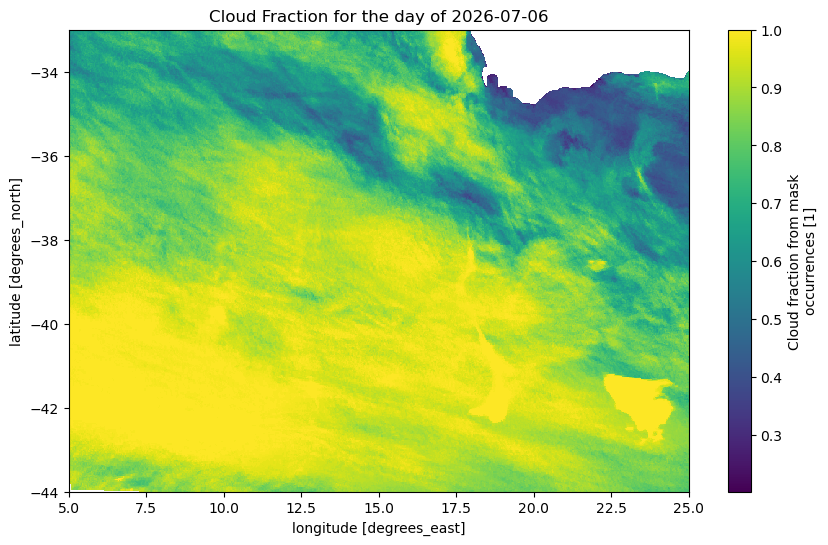

In [59]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 6))

ds['cloud_fraction'].plot(ax=ax)

ax.set_title(f'Cloud Fraction for the day of {pd.to_datetime(ds.end_time.values).date()}')

In [ ]:
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display

if 'time' not in ds['BT'].dims or ds.sizes.get('time', 0) == 0:
    raise ValueError('ds["BT"] has no time dimension or contains no time steps.')

bt = ds['mask']
vmin = float(bt.min().compute())
vmax = float(bt.max().compute())

slider = widgets.IntSlider(
    value=0,
    min=0,
    max=ds.sizes['time'] - 1,
    step=1,
    description='t idx',
    continuous_update=False,
    style={'description_width': 'initial'},
)

play = widgets.Play(
    value=0,
    min=0,
    max=ds.sizes['time'] - 1,
    step=1,
    interval=700,
    description='Play',
)
widgets.jslink((play, 'value'), (slider, 'value'))

def plot_bt(t_idx):
    fig, ax = plt.subplots(figsize=(7, 6))
    bt.isel(time=t_idx).plot(ax=ax, cmap='viridis', vmin=vmin, vmax=vmax)
    ax.set_title(f"BT at {pd.to_datetime(bt.time.isel(time=t_idx).values)}")
    plt.show()

controls = widgets.HBox([play, slider])
out = widgets.interactive_output(plot_bt, {'t_idx': slider})
display(controls, out)

In [13]:
today_start.date()

datetime.date(2026, 7, 6)

<xarray.Dataset> Size: 1GB
Dimensions:           (time: 119, lat: 550, lon: 1000)
Coordinates:
  * time              (time) datetime64[ns] 952B 2026-07-05T04:10:00 ... 2026...
  * lat               (lat) float64 4kB -43.99 -43.97 -43.95 ... -33.03 -33.01
  * lon               (lon) float64 8kB 5.01 5.03 5.05 ... 24.95 24.97 24.99
Data variables:
    BT                (time, lat, lon) float32 262MB dask.array<chunksize=(4, 275, 500), meta=np.ndarray>
    loggrad_T         (time, lat, lon) float32 262MB dask.array<chunksize=(4, 275, 500), meta=np.ndarray>
    mask              (time, lat, lon) float32 262MB dask.array<chunksize=(4, 275, 500), meta=np.ndarray>
    loggrad_T_masked  (time, lat, lon) float32 262MB dask.array<chunksize=(4, 275, 500), meta=np.ndarray>
    cloud_fraction    (lat, lon) float64 4MB nan nan nan nan ... nan nan nan nan
    BT_masked         (time, lat, lon) float32 262MB dask.array<chunksize=(4, 275, 500), meta=np.ndarray>
    BT_masked_max     (lat, lon) float32 2MB dask.array<chunksize=(275, 500), meta=np.ndarray>
Attributes:
    title:        FCI ir_105 brightness temperature, gradient, and cloud mask
    source:       RRAD: 202607050410-202607050500_FCI-1C-RRAD_0p02deg.nc; CLM...
    Conventions:  CF-1.8

In [ ]:
import os
import pandas as pd

start_time = pd.to_datetime(ds.time.min().values)
end_time = pd.to_datetime(ds.time.max().values)

start_stamp = start_time.strftime('%Y%m%d')
end_stamp = end_time.strftime('%Y%m%d')

start_stamp = start_time.strftime('%Y%m%dT%H')
# end_stamp = end_time.strftime('%Y%m%dT%H')

output_dir = '/home/mduplessis/share/EUMETSAT/goflow_daily_means/'
output_filename = f'BT_masked_Meteosat_{start_stamp}_{end_stamp}.nc'
output_path = os.path.join(output_dir, output_filename)
tmp_output_path = f'{output_path}.tmp'
os.makedirs(output_dir, exist_ok=True)

bt_to_save = ds['BT_masked'].copy()
bt_to_save.name = 'BT_masked'
bt_to_save = bt_to_save.max(dim='time').load()
bt_to_save.attrs.update({
    'long_name': 'Masked brightness temperature',
    'units': 'C',
    'start_time': start_time.isoformat(),
    'end_time': end_time.isoformat(),
})

cloud_count = (ds['mask'] == 1).sum(dim='time', skipna=True).load()
valid_count = ds['mask'].count(dim='time').load()
cloud_fraction = xr.where(valid_count > 0, cloud_count / valid_count, float('nan'))
cloud_fraction.name = 'cloud_fraction'
cloud_fraction.attrs.update({
    'long_name': 'Cloud fraction from mask occurrences',
    'units': '1',
    'description': 'Per-pixel fraction of times mask == 1 over available time samples',
    'start_time': start_time.isoformat(),
    'end_time': end_time.isoformat(),
})

ds_out = bt_to_save.to_dataset()

ds_out['start_time'] = xr.DataArray(
    start_time.to_datetime64(),
    attrs={
        'long_name': 'Start time of source data range',
    },
)
ds_out['end_time'] = xr.DataArray(
    end_time.to_datetime64(),
    attrs={
        'long_name': 'End time of source data range',
    },
)
ds_out.attrs.update({
    'start_time': start_time.isoformat(),
    'end_time': end_time.isoformat(),
})

if os.path.exists(tmp_output_path):
    os.remove(tmp_output_path)

ds_out.to_netcdf(tmp_output_path, mode='w')
os.replace(tmp_output_path, output_path)

ds.close()

print(f'Saved {bt_to_save.name} and cloud_fraction to {output_path}')
print(f"time_coverage_start: {bt_to_save.attrs['start_time']}")
print(f"time_coverage_end: {bt_to_save.attrs['end_time']}")

/home/mduplessis/sw/miniconda3/envs/data/lib/python3.13/site-packages/dask/array/reductions.py:325: RuntimeWarning: All-NaN slice encountered
  return np.nanmax(x_chunk, axis=axis, keepdims=keepdims)


Saved BT_masked and cloud_fraction to /home/mduplessis/share/EUMETSAT/goflow_daily_means/BT_masked_Meteosat_20260706_20260706.nc
time_coverage_start: 2026-07-06T00:00:00
time_coverage_end: 2026-07-06T07:00:00
